In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import fsolve
from functools import partial
from matplotlib.lines import Line2D

# used to import local files
import sys  
sys.path.insert(1, '/cluster/tufts/mggg/cdonna01/EC_paper/refactored_2_bloc_stv')

from BT_coh_to_fpv import *

def upper_cone_optimize(data, upper = 1000.0, lower = -100.0, precision = 1, data_total = .95, point_on_line = (.5,.5), xlim = .53):
    """
    Find the minimal slope line going through .5,.5 such that data_total percent of data lies below
    the line.

    Upper: the initial slope of the upper bound line
    Lower: the initial slope of the lower bound line.
    Precision: to what distance do we want the upper and lower bound to match.
    data_total: what percent of data should lie below the line.
    point_on_line: a point that must be on the line.

    return m,b where m is the slope and b is the y-intercept
    """
    target_point_count = int(data_total * len([(x,y) for x,y in data if x >= xlim]))

    proposed_slope = (upper+lower)/2
    b = point_on_line[1]-proposed_slope*point_on_line[0]

    # until we reach desired precision
    while abs(upper-lower) > precision:
        num_contained_points = len([(x,y) for x,y in data if y<= proposed_slope*x+b and x >= xlim])

        # if too few points, we have a new lower bound
        if num_contained_points <= target_point_count:
            lower = proposed_slope
        # if too many points we have a new upper bound
        else:
            upper = proposed_slope
        
        # average the old bounds, compute y intercept
        proposed_slope = (upper+lower)/2
        b = point_on_line[1]-proposed_slope*point_on_line[0]
    
    
    return proposed_slope, b


def lower_cone_optimize(data, upper = 100.0, lower = -1000.0, precision = 1, data_total = .95, point_on_line = (.5,.5), xlim = .53):
    """
    Find the minimal slope line going through .5,.5 such that data_total percent of data lies above
    the line.

    Upper: the initial slope of the upper bound line
    Lower: the initial slope of the lower bound line.
    Precision: to what distance do we want the upper and lower bound to match.
    data_total: what percent of data should lie above the line.
    point_on_line: a point that must be on the line.

    return m,b where m is the slope and b is the y-intercept
    """
    target_point_count = int(data_total * len([(x,y) for x,y in data if x >= xlim]))
    # print("target", target_point_count)                

    proposed_slope = (upper+lower)/2
    b = point_on_line[1]-proposed_slope*point_on_line[0]

    # until we reach desired precision
    while abs(upper-lower) > precision:
        num_contained_points = len([(x,y) for x,y in data if y>= proposed_slope*x+b and x >= xlim])
        # print("num_contained", num_contained_points)

        # if too few points, we have a new upper bound
        if num_contained_points <= target_point_count:
            upper = proposed_slope
        # if too many points we have a new lower bound
        else:
            lower = proposed_slope
        
        # average the old bounds, compute y intercept
        proposed_slope = (upper+lower)/2
        b = point_on_line[1]-proposed_slope*point_on_line[0]
    
    
    return proposed_slope, b


In [2]:
b_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
a_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
b_prop_list = [x/100 for x in range(5, 100, 10)]


generators=["slate-PL"]

# relabel from OG data runs
pi_types_dict = {"U": "UUUU", 
                "XA":"XUXU" ,
                "XB":"UXUX",
                "AX":"XXUU",
                "BX":"UUXX",
                "X": "XXXX"}


pi_types_colors = {"U":'#1560BD', 
"XA":'#FB607F', 
"XB":'#8DB600',
"BX":'#FFBF00',
"AX": '#8B008B',
"X": '#E32636'}

# Dirichlet


In [3]:
N_TRIALS = 100
N_BALLOTS = 1000
N_SEATS = 6
N_CANDS_PER_BLOC = 6

uniform_dirichlet = 2.0
strong_dirichlet = .5

election_path_name = f'./election_results/2_bloc/dirichlet/trials_{N_TRIALS}_ballots_{N_BALLOTS}_seats_{N_SEATS}_cperbloc_{N_CANDS_PER_BLOC}'


In [4]:
b_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
a_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
b_prop_list = [x/100 for x in range(5, 100, 10)]

dirichlet_dfs = {}
for b_coh in b_coh_list:
    for g in generators:
        for pi_type in pi_types_dict.keys():
            for b_prop in b_prop_list:
                for a_coh in a_coh_list:
                    df = pd.read_csv(f"{election_path_name}/b_coh_{b_coh}_a_coh_{a_coh}_b_prop_{b_prop}_{g}_pi_type_{pi_type}_dunif_{uniform_dirichlet}_dstrong_{strong_dirichlet}/b_coh_{b_coh}_a_coh_{a_coh}_b_prop_{b_prop}_{g}_pi_type_{pi_type}_dunif_{uniform_dirichlet}_dstrong_{strong_dirichlet}.csv", index_col=0)
                    dirichlet_dfs[(b_coh, g, pi_type, b_prop, a_coh)] = df
                    
                   

/cluster/tufts/mggg/cdonna01/EC_paper/refactored_2_bloc_stv/election_results/2_bloc/dirichlet/trials_100_ballots_1000_seats_6_cperbloc_6/b_coh_0.5_a_coh_0.5_b_prop_0.05_slate-PL_pi_type_U_dunif_2.0_dstrong_0.5/b_coh_0.5_a_coh_0.5_b_prop_0.05_slate-PL_pi_type_U_dunif_2.0_dstrong_0.5.csv


# Waterfall plots for full param space, with/without LOBF

about 3 min per plot

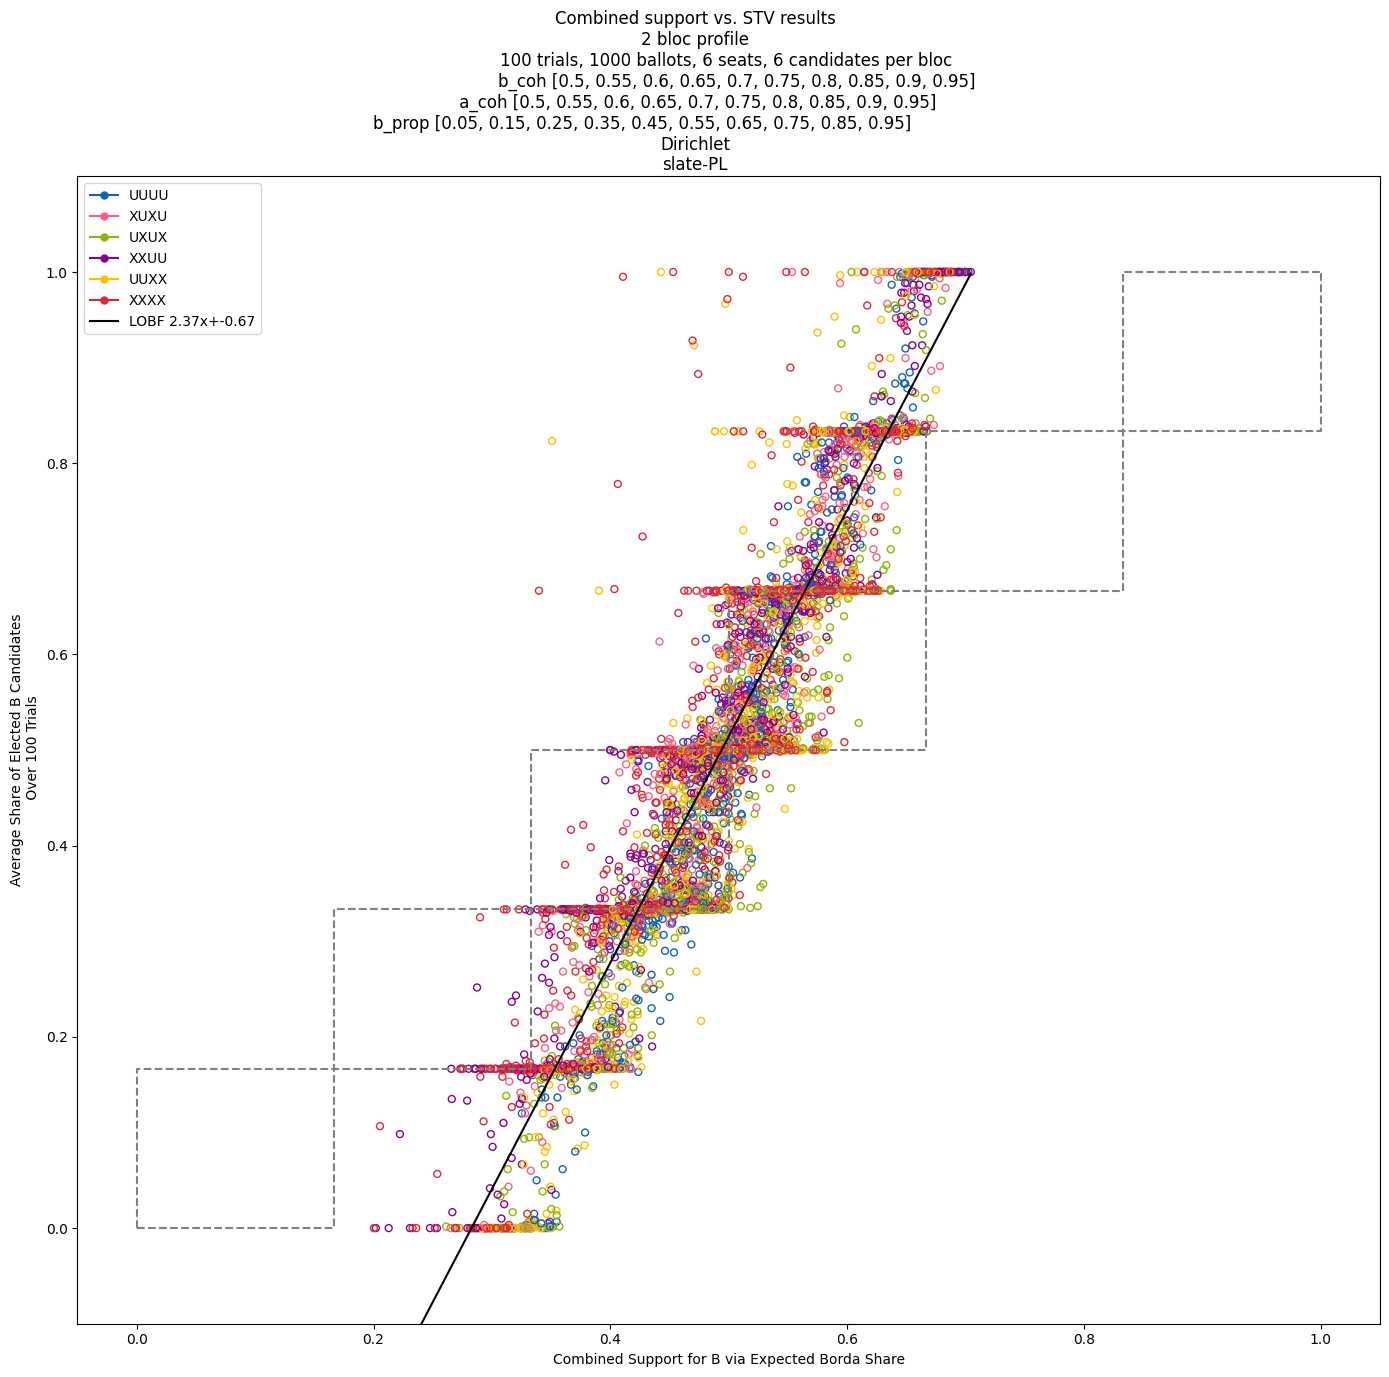

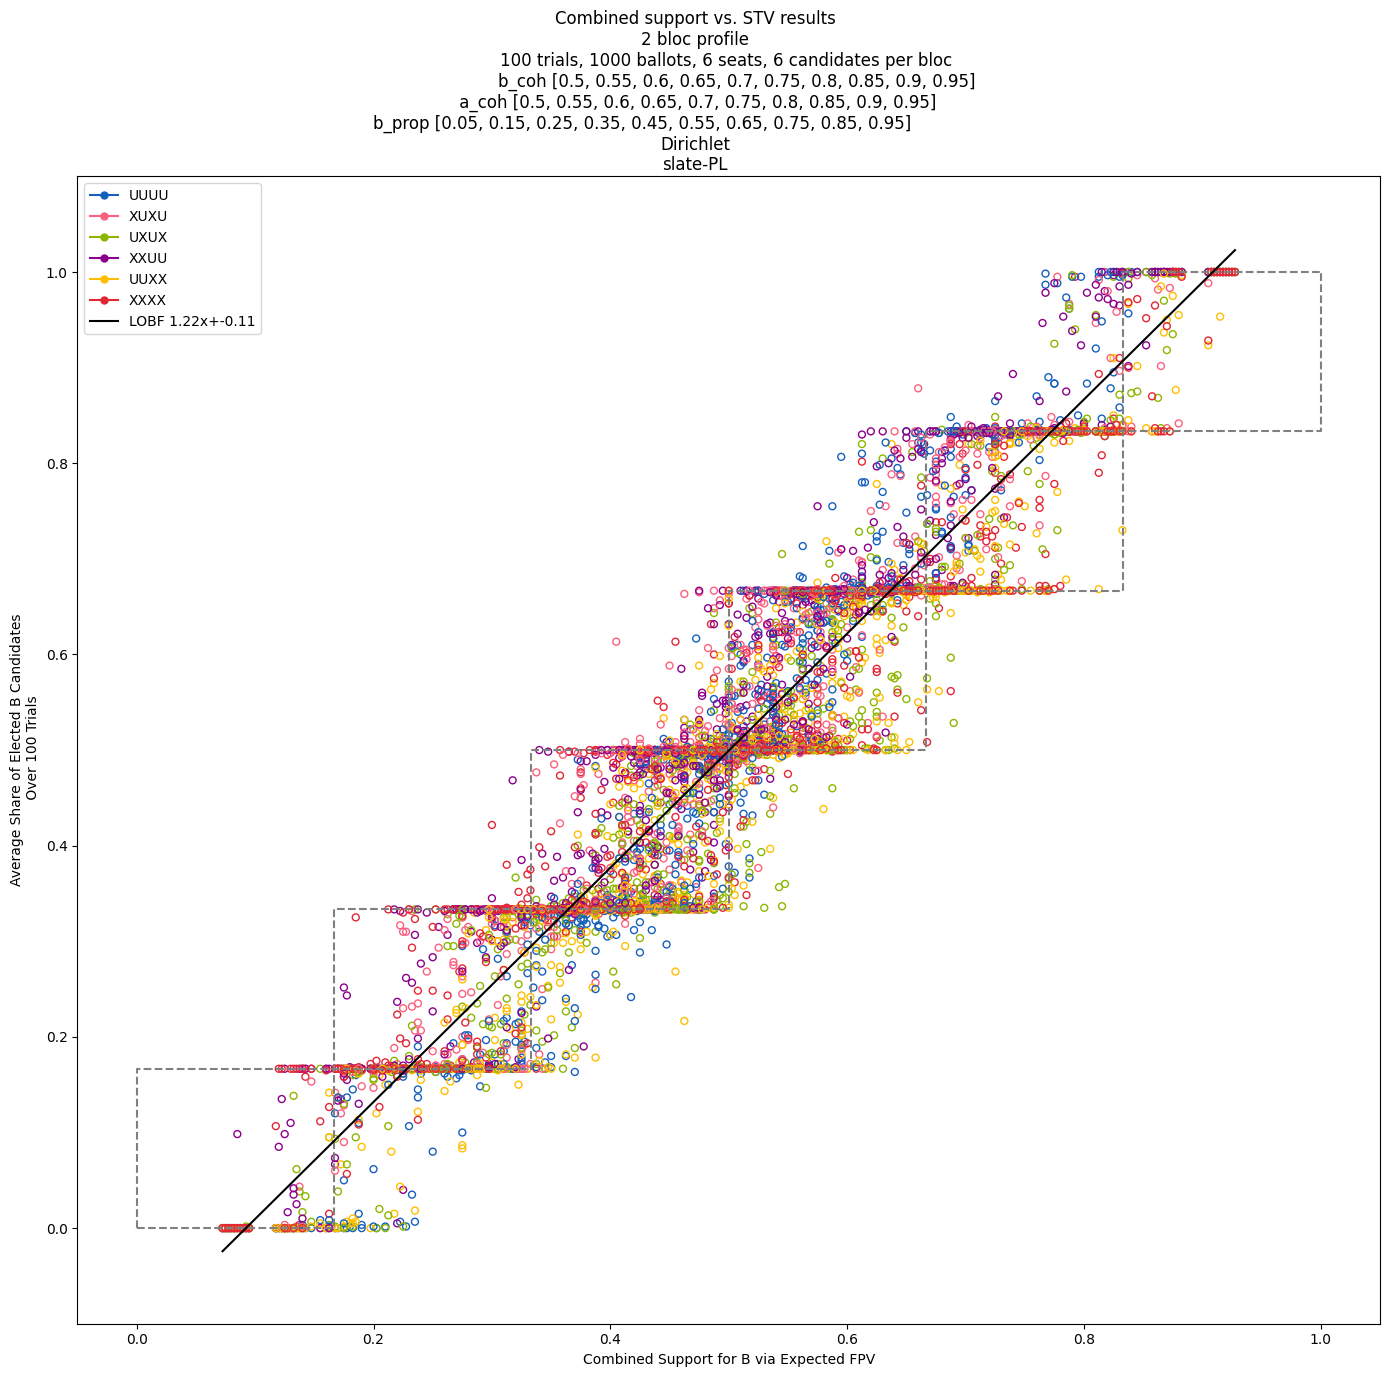

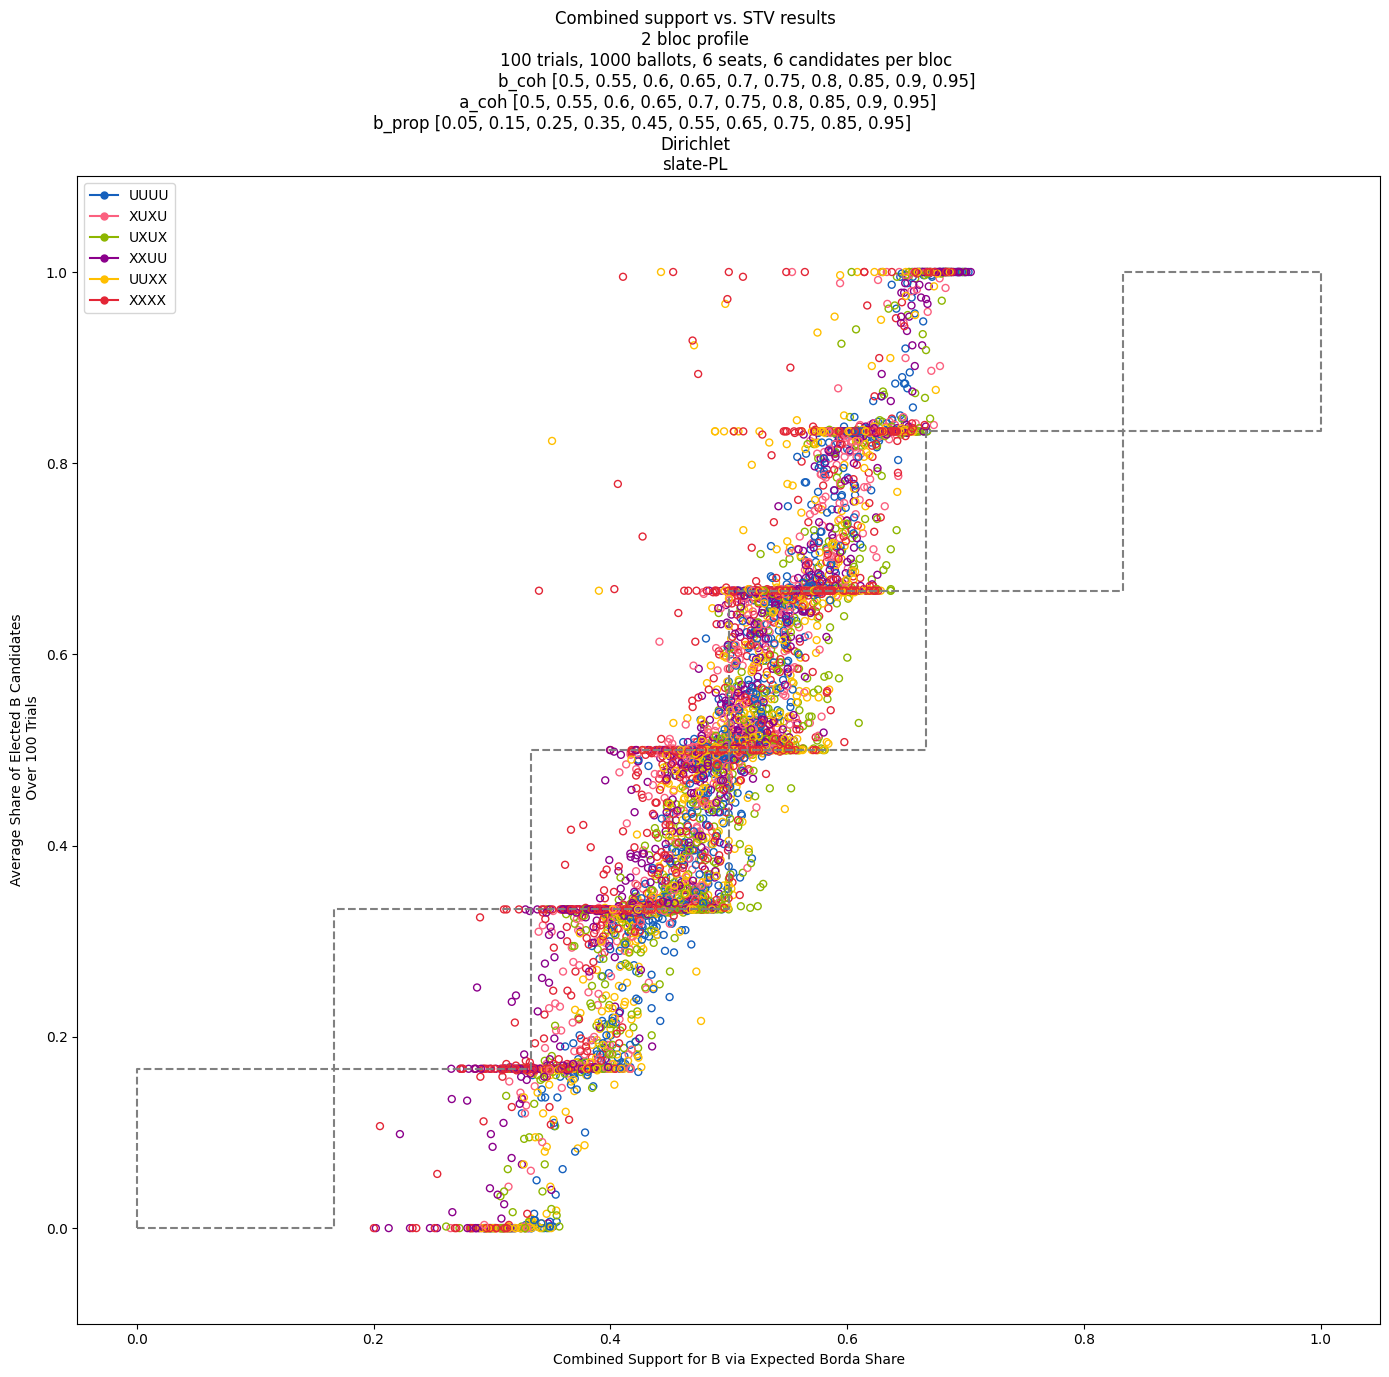

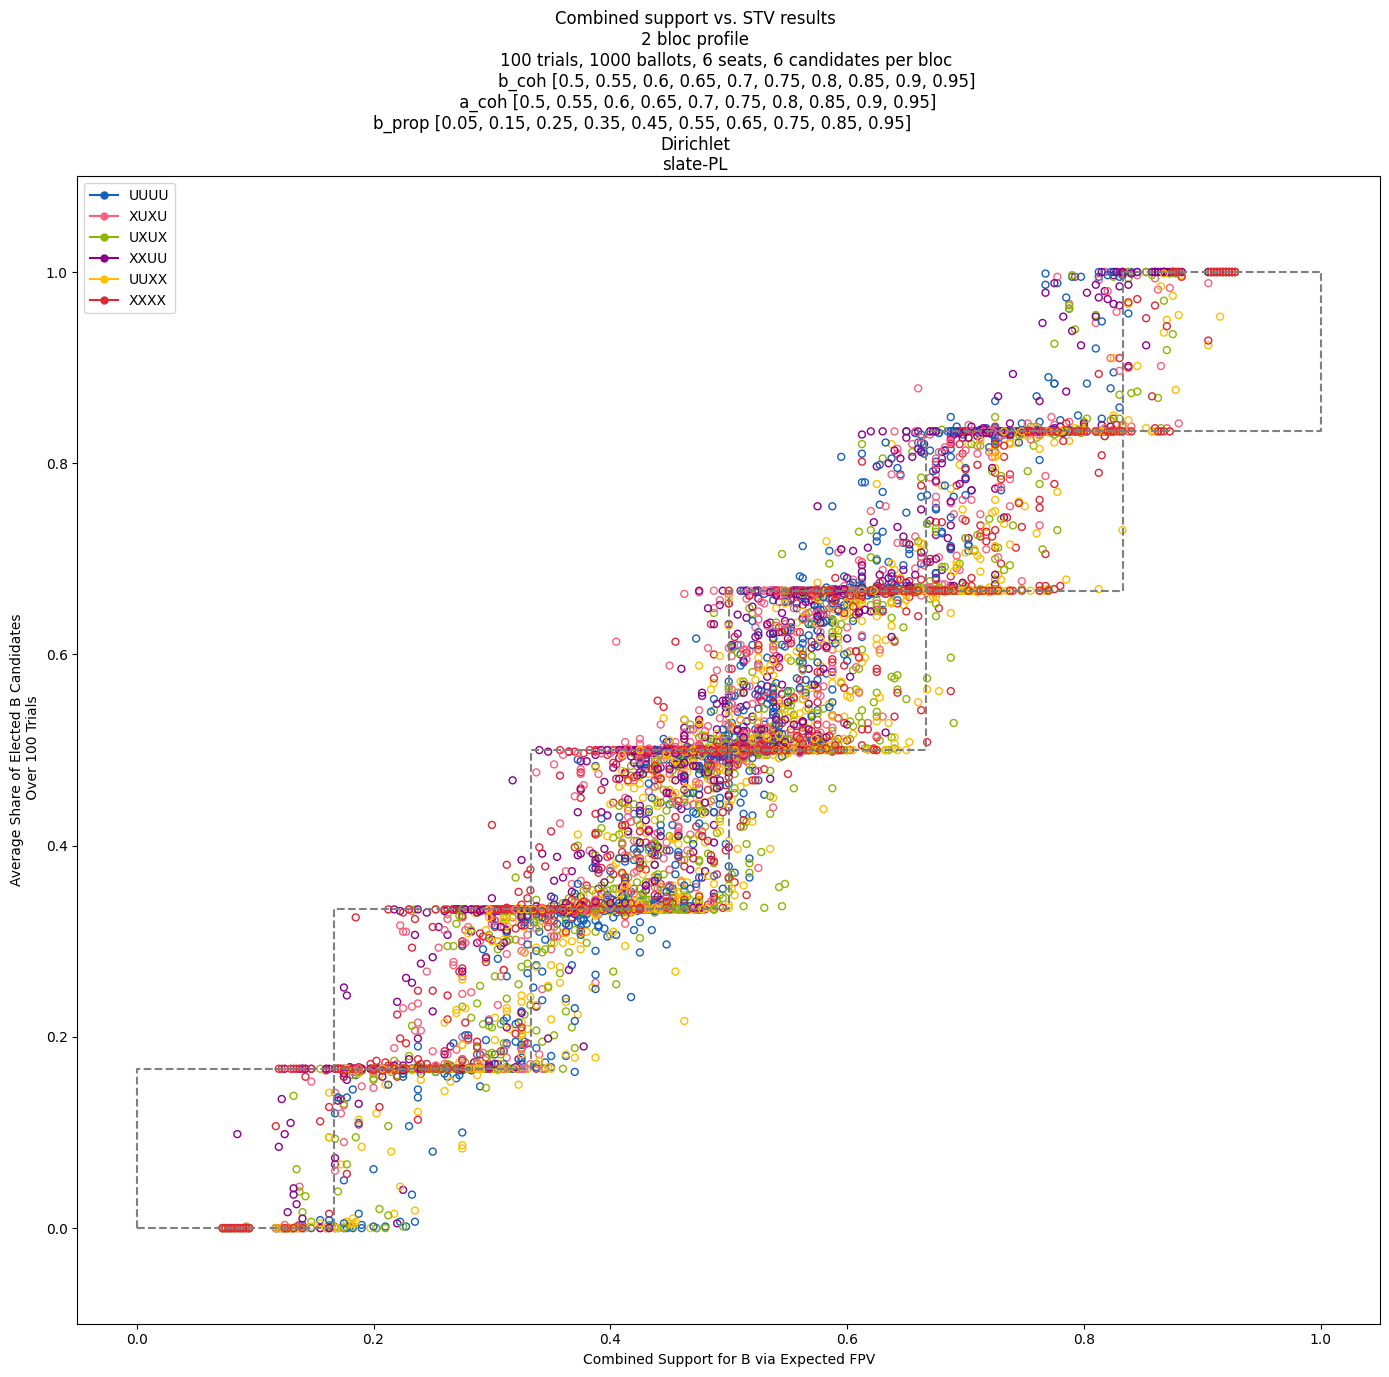

In [5]:
b_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
a_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
b_prop_list = [x/100 for x in range(5, 100, 10)]


for LINES in [True, False]:
    for STAT in ["Expected Borda Share", "Expected FPV"]:


        fig, ax = plt.subplots(figsize=(14,14))
        ax.step(
            np.linspace(0,1,N_SEATS+1),
            np.arange(0,1.1, 1/N_SEATS),
            linestyle = 'dashed',
            c='gray',
            where='pre'
        )
        ax.step(
            np.linspace(0,1,N_SEATS+1),
            np.arange(0,1.1, 1/N_SEATS),
            linestyle = 'dashed',
            c='gray',
            where='post'
        )
        ax.set_ylabel(f'Average Share of Elected B Candidates\n Over {N_TRIALS} Trials')
        ax.set_xlabel(f'Combined Support for B via {STAT}')

        data  = [-1]* len(generators)*len(b_prop_list)*len(pi_types_dict)*len(b_coh_list)*len(a_coh_list)
        i=0
        for g in generators:
            for b_prop in b_prop_list:
                for pi_type, pi_label in pi_types_dict.items():
                    for b_coh in b_coh_list:
                        if "BT" in g:
                            fpv_b = slate_BT_coh_to_fpv(N_CANDS_PER_BLOC, N_CANDS_PER_BLOC, b_coh)
                        else:
                            fpv_b=b_coh
                        for a_coh in a_coh_list:
                            if "BT" in g:
                                fpv_a = slate_BT_coh_to_fpv(N_CANDS_PER_BLOC, N_CANDS_PER_BLOC, a_coh)
                            else:
                                fpv_a=a_coh
                            df = dirichlet_dfs[(b_coh, g, pi_type, b_prop, a_coh)]
                            
                            # combined support
                            if "Borda" in STAT:
                                x=np.average(df["B Borda shares"])
                            
                            else:
                                x = fpv_b*b_prop  + (1-fpv_a)*(1-b_prop)
                            
                            # average seats over trials
                            y = np.average(df["B cands elected"])/N_SEATS 

                            if LINES:
                                data[i]=(x,y)
                                i+=1               
                            ax.scatter(x, y,
                                    label=pi_label,
                                    marker=".",
                                    edgecolor=pi_types_colors[pi_type], 
                                    facecolor='none', s=100,
                                )
                                
                    


        if LINES:
            x = np.linspace(0, 1, 100)  

            # line of best fit
            x,y = zip(*data)
            m_3=np.polyfit(x, y, 1)[0]
            b_3=np.polyfit(x, y, 1)[1]
            plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)), color="black", label=f"LOBF {m_3:.2f}x+{b_3:.2f}")


        legend_elements = [
            Line2D([0], [0], marker=".", color=pi_types_colors[pi_type], label=pi_label, markersize=10)
            for pi_type, pi_label in pi_types_dict.items()
        ] 

        if LINES:
            legend_elements += [Line2D([0], [0], color="black", label=f"LOBF {m_3:.2f}x+{b_3:.2f}")]
            


        plt.ylim(-.1, 1.1)
        plt.legend(handles=legend_elements)
        plt.suptitle(f"Combined support vs. STV results\n2 bloc profile\n\
            {N_TRIALS} trials, {N_BALLOTS} ballots, {N_SEATS} seats, {N_CANDS_PER_BLOC} candidates per bloc\n\
                b_coh {b_coh_list}\n a_coh {a_coh_list}\nb_prop {b_prop_list}\
                    \nDirichlet\nslate-PL")
        plt.tight_layout()
        # plt.show()
        if LINES:   
            plt.savefig(f"./figures/2_bloc/dirichlet/line_fit/lines_sPL_{N_SEATS}_seats_combined_support_{STAT}_STV.png", dpi=300)
        else:
            plt.savefig(f".figures/2_bloc/dirichlet/sPL_{N_SEATS}_seats_combined_support_{STAT}_STV.png", dpi=300)


# Waterfall plots for slices of param space, cone slopes, and LOBF
- doesn't plot cone
- tries different cone limits, .53 through .56
- runs in about 27 minutes

In [7]:
slopes = {"generator":[],
            "pi_type":[],
            "cohesion":[],}

slopes.update({f"xlim {lim} {cone} {stat}":[] for lim in [.53,.54,.55,.56] for cone in ["UC", "LC", "LOBF"] for stat in ["m", "b"]})


for STAT in ["Expected FPV", "Expected Borda Share"]:
    for g in generators:
        for pi_type, pi_label in pi_types_dict.items():
            for cohesion in ["full", "polarized"]:
                print(g, pi_type, f"cohesion {cohesion}")
                slopes["generator"].append(g)
                slopes["pi_type"].append(pi_type)
                slopes["cohesion"].append(cohesion)

                if cohesion == "full":
                    b_coh_list = [round(x, 2) for x in np.arange(0.55, .99, 0.05)]
                    a_coh_list = [round(x, 2) for x in np.arange(0.55, .99, 0.05)]
                else:
                    b_coh_list = [round(x, 2) for x in np.arange(0.7, .99, 0.05)]
                    a_coh_list = [round(x, 2) for x in np.arange(0.7, .99, 0.05)]


                b_prop_list = [x/100 for x in range(5, 100, 10)]

                for lines in [True, False]:
                    for lim in [.53,.54,.55,.56]:
                        print("xlim,", lim)
                        fig, ax = plt.subplots(figsize=(14,14))
                        ax.step(
                            np.linspace(0,1,N_SEATS+1),
                            np.arange(0,1.1, 1/N_SEATS),
                            linestyle = 'dashed',
                            c='gray',
                            where='pre'
                        )
                        ax.step(
                            np.linspace(0,1,N_SEATS+1),
                            np.arange(0,1.1, 1/N_SEATS),
                            linestyle = 'dashed',
                            c='gray',
                            where='post'
                        )
                        ax.set_ylabel(f'Average Share of Elected B Candidates\n Over {N_TRIALS} Trials')
                        ax.set_xlabel(f'Combined Support for B via {STAT}')
                    
                        data  = [-1]*len(b_prop_list)*len(b_coh_list)*len(a_coh_list)
                        i=0
                        for b_prop in b_prop_list:
                            for b_coh in b_coh_list:
                                if "BT" in g:
                                    fpv_b = slate_BT_coh_to_fpv(N_CANDS_PER_BLOC, N_CANDS_PER_BLOC, b_coh)
                                else:
                                    fpv_b=b_coh
                                for a_coh in a_coh_list:
                                    if "BT" in g:
                                        fpv_a = slate_BT_coh_to_fpv(N_CANDS_PER_BLOC, N_CANDS_PER_BLOC, a_coh)
                                    else:
                                        fpv_a=a_coh
                                    df = dirichlet_dfs[(b_coh, g, pi_type, b_prop, a_coh)]
                                    # combined support
                                    if "Borda" in STAT:
                                        x=np.average(df["B Borda shares"])
                                    else:
                                        x = fpv_b*b_prop  + (1-fpv_a)*(1-b_prop)
                                    
                                    # average seats over trials
                                    y = np.average(df["B cands elected"])/N_SEATS 

                                    data[i]=(x,y)
                                    i+=1
                                    ax.scatter(x, y,
                                        label=pi_label,
                                        marker=".",
                                        edgecolor=pi_types_colors[pi_type], 
                                        facecolor='none', s=100,
                                    )
                            

                    
                        if lines:                
                            x = np.linspace(0, 1, 100)  
                            m_1,b_1 = upper_cone_optimize(data, 
                                        upper = 1000.0, 
                                        lower = -100.0, 
                                        precision = .01, 
                                        data_total = .95, 
                                        point_on_line = (.5, .5), 
                                        xlim = lim)
                            y = m_1*x+b_1
                            # plt.plot(x,y, label = f"upper cone {m_1:.2f}x+{b_1:.2f}", color="red")
                            print(f"upper cone {m_1:.2f}x+{b_1:.2f}")
                            slopes[f"xlim {lim} UC m"].append(m_1)
                            slopes[f"xlim {lim} UC b"].append(b_1)

                            # print("lower cone")
                            m_2,b_2 = lower_cone_optimize(data, 
                                        upper = 1000.0, 
                                        lower = -100.0, 
                                        precision = .01, 
                                        data_total = .95, 
                                        point_on_line = (.5, .5), 
                                        xlim = lim)
                            y = m_2*x+b_2
                            # plt.plot(x,y, label = f"lower cone {m_2:.2f}x+{b_2:.2f}", color="blue")

                            print(f"lower cone {m_2:.2f}x+{b_2:.2f}")
                            slopes[f"xlim {lim} LC m"].append(m_2)
                            slopes[f"xlim {lim} LC b"].append(b_2)

                            # line of best fit
                            x,y = zip(*data)
                            m_3=np.polyfit(x, y, 1)[0]
                            b_3=np.polyfit(x, y, 1)[1]
                            plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)), color="black",  label=f"LOBF {m_3:.2f}x+{b_3:.2f}")

                            print(f"LOBF {m_3:.2f}x+{b_3:.2f}\n")
                            slopes[f"xlim {lim} LOBF m"].append(m_3)
                            slopes[f"xlim {lim} LOBF b"].append(b_3)

                            legend_elements = [
                                            Line2D([0], [0], marker=".", color=pi_types_colors[pi_type], label=pi_label, markersize=10)
                                            
                                        ]   +[Line2D([0], [0], color="black",  label=f"LOBF {m_3:.2f}x+{b_3:.2f}")]
                                # [Line2D([0], [0], color="red", label = f"upper cone {m_1:.2f}x+{b_1:.2f}")
                                # ] + \
                                # [Line2D([0], [0], color="blue", label = f"lower cone {m_2:.2f}x+{b_2:.2f}")]+ \
                                
                        else:
                            legend_elements = [
                                    Line2D([0], [0], marker=".", color=pi_types_colors[pi_type], label=pi_label, markersize=10)
                                ] 

                        plt.ylim(-.1, 1.1)
                        plt.legend(handles=legend_elements)
                        plt.suptitle(f"Combined support vs. STV results\n2 bloc profile\n{N_TRIALS} trials, {N_BALLOTS} ballots, {N_SEATS} seats, {N_CANDS_PER_BLOC} candidates per bloc\npi_B {b_coh_list}\npi_A {a_coh_list}\nb_prop {b_prop_list}\nDirichlet\n xlim {lim}")
                        plt.tight_layout()
                        # plt.show()

                        if lines:
                            plt.savefig(f"/cluster/tufts/mggg/cdonna01/EC_paper/refactored_2_bloc_stv/figures/2_bloc/dirichlet/line_fit/sPL_xlim_{lim}_{N_SEATS}_seats_{STAT}_combined_support_STV_{g}_{pi_type}_{cohesion}.png", dpi=300)
                        else:
                            plt.savefig(f"/cluster/tufts/mggg/cdonna01/EC_paper/refactored_2_bloc_stv/figures/2_bloc/dirichlet/sPL_{N_SEATS}_seats_{STAT}_combined_support_STV_{g}_{pi_type}_{cohesion}.png", dpi=300)
                        
                        plt.close()
            
        
        

    data_frame = pd.DataFrame.from_dict(slopes)
    data_frame.to_csv(f"/cluster/tufts/mggg/cdonna01/EC_paper/refactored_2_bloc_stv/slope_data/dirichlet/sPL_{N_SEATS}_seats_slopes_2_bloc_stv_{STAT}.csv")

slate-PL U cohesion full
xlim, 0.53
upper cone 2.49x+-0.75
lower cone 0.11x+0.45
LOBF 1.37x+-0.19

xlim, 0.54
upper cone 2.43x+-0.72
lower cone 0.37x+0.32
LOBF 1.37x+-0.19

xlim, 0.55
upper cone 2.42x+-0.71
lower cone 0.97x+0.01
LOBF 1.37x+-0.19

xlim, 0.56
upper cone 2.20x+-0.60
lower cone 0.98x+0.01
LOBF 1.37x+-0.19

xlim, 0.53
xlim, 0.54
xlim, 0.55
xlim, 0.56
slate-PL U cohesion polarized
xlim, 0.53
upper cone 2.20x+-0.60
lower cone 0.12x+0.44
LOBF 1.35x+-0.18

xlim, 0.54
upper cone 2.20x+-0.60
lower cone 0.23x+0.39
LOBF 1.35x+-0.18

xlim, 0.55
upper cone 2.09x+-0.54
lower cone 0.96x+0.02
LOBF 1.35x+-0.18

xlim, 0.56
upper cone 1.93x+-0.46
lower cone 0.98x+0.01
LOBF 1.35x+-0.18

xlim, 0.53
xlim, 0.54
xlim, 0.55
xlim, 0.56
slate-PL XA cohesion full
xlim, 0.53
upper cone 2.89x+-0.94
lower cone -0.00x+0.50
LOBF 1.21x+-0.09

xlim, 0.54
upper cone 2.38x+-0.69
lower cone 0.02x+0.49
LOBF 1.21x+-0.09

xlim, 0.55
upper cone 2.20x+-0.60
lower cone 0.05x+0.48
LOBF 1.21x+-0.09

xlim, 0.56
upper

: 